In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from datasets import Dataset
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification, 
)

from sklearn.manifold import TSNE

from dotenv import load_dotenv
import os
load_dotenv()
YOUR_HF_TOKEN = os.getenv("YOUR_HF_TOKEN")

/home/bistreamt/Desktop/master/research 3/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Define your mapping
path_dist = "data/regional-court-data.json"
path_sup = "data/supreme-court-data.json"

def prepare_dataset(json_file_path, task):
    with open(json_file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    if "sup" in json_file_path:
        label_map = {
            "respins": 0,
            "admis": 1,
            "inadmisibil": 2,
        }
        if task == 2:
            data = [item for item in data if item['label'] != 'inadmisibil']
    else:
        label_map = {
            "vinovat": 0,
            "nevinovat": 1
        }
    formatted_data = []
    for entry in data:
        # Combine description (1-8) and justification (1-4)
        desc = " ".join([entry.get(f"case_description_{i}", "") for i in range(1, 9)]).strip()
        # just = " ".join([entry.get(f"justification_{i}", "") for i in range(1, 5)]).strip()
        
        formatted_data.append({
            "text": f"{desc}", # Description prioritized by order
            "label": label_map[entry["label"]]
        })

    
    return Dataset.from_list(formatted_data)



In [4]:
def visualize_tsne(path, model, tokenizer, llm, title, task=0):    
    # 1. Load the full dataset
    data = prepare_dataset(path, task)

    # --- NEW: BALANCED STRATIFIED SAMPLING BLOCK ---
    print("Balancing dataset labels for t-SNE...")

    # Filter the dataset by label
    class_0_dataset = data.filter(lambda x: x["label"] == 0)
    class_1_dataset = data.filter(lambda x: x["label"] == 1)
    if task == 3:
        class_2_dataset = data.filter(lambda x: x["label"] == 2)

    # Find the maximum possible equal sample size (target max 200 per class for a total of 400)
    max_per_class = min(200, len(class_0_dataset), len(class_1_dataset))
    if task == 3:
        max_per_class = min(max_per_class, len(class_2_dataset))
    print(f"Sampling an equal distribution of {max_per_class} items per label (Total: {max_per_class * 2})")

    # Select matching ranges from both classes
    subset_0 = class_0_dataset.select(range(max_per_class))
    subset_1 = class_1_dataset.select(range(max_per_class))
    if task == 3:
        subset_2 = class_2_dataset.select(range(max_per_class))


    # Concatenate them back together using Hugging Face datasets library tools
    from datasets import concatenate_datasets
    subset = concatenate_datasets([subset_0, subset_1])
    if task == 3:
        subset = concatenate_datasets([subset, subset_2])

    # Shuffle the combined dataset so the labels aren't strictly blocked together
    subset = subset.shuffle(seed=42)

    # Extract texts and labels for embedding processing
    texts = subset["text"]
    labels = subset["label"]
    # -----------------------------------------------

    # 3. Programmatically extract the Latent Space Embeddings
    embeddings = []
    print("Extracting high-dimensional embeddings...")
    with torch.no_grad():
        for text in texts:
            inputs = tokenizer(text, truncation=True, padding="max_length", max_length=512, return_tensors="pt").to(device)
            outputs = model(**inputs, output_hidden_states=True)

            # We extract the [CLS] token embedding (first token) as the sentence representation
            if llm==True:
                attention_mask = inputs["attention_mask"][0]
                last_token_index = torch.sum(attention_mask) - 1
                
                # 3. Pull the embedding from the final hidden layer (-1) at the last token position
                final_layer = outputs.hidden_states[-1] # Shape: (1, sequence_length, hidden_dim)
                sequence_embedding = final_layer[0, last_token_index, :].cpu().numpy()
                
                embeddings.append(sequence_embedding)

            else:
                cls_embedding = outputs.hidden_states[-1][0, 0, :].cpu().numpy()
                embeddings.append(cls_embedding)

    embeddings = np.array(embeddings) # Matrix shape: (Samples, 768)

    # 4. Compute t-SNE (Squash 768 dimensions down to 2)
    print("Computing t-SNE dimensionality reduction...")
    # Note: fixed 'max_iter' parameter from your code block to the proper scikit-learn 'n_iter' parameter
    tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
    embeddings_2d = tsne.fit_transform(embeddings) # Shape: (Samples, 2)

    # 5. Plot the results for your Thesis
    plt.figure(figsize=(10, 8), dpi=300) # High resolution for print publishing

    # Separate data points by label for clean plotting and legend building
    x = embeddings_2d[:, 0]
    y = embeddings_2d[:, 1]

    # Mapping names dynamically to match your label definitions
    if task == 2:
        label_names_map = {
            0: "Class 0 (Rejected / \"Respins\")",
            1: "Class 1 (Admitted / \"Admis\")"
        }
    elif task == 3:
        label_names_map = {
            0: "Class 0 (Rejected / \"Respins\")",
            1: "Class 1 (Admitted / \"Admis\")",
            2: "Class 2 (Inadmissible / \"Inadmisibil\")"
        }
    else:
        label_names_map = {
            0: "Class 0 (Guilty / \"Vinovat\")",
            1: "Class 1 (Not Guilty / \"Nevinovat\")"
        }

    if task == 3:
        for target_label, color in [(0, "crimson"), (1, "dodgerblue"), (2, "forestgreen")]:
            indices = [i for i, l in enumerate(labels) if l == target_label]
            plt.scatter(
                x[indices], 
                y[indices], 
                c=color, 
                label=label_names_map[target_label], 
                alpha=0.7, 
                edgecolors="none", 
                s=35
            )
    else:
        for target_label, color in [(0, "crimson"), (1, "dodgerblue")]:
            indices = [i for i, l in enumerate(labels) if l == target_label]
            plt.scatter(
                x[indices], 
                y[indices], 
                c=color, 
                label=label_names_map[target_label], 
                alpha=0.7, 
                edgecolors="none", 
                s=35
            )

    # Formatting standardizations for academic papers
    plt.title(f"t-SNE Visualization of {title}", fontsize=14, fontweight="bold", pad=15)
    plt.xlabel("t-SNE Dimension 1", fontsize=12)
    plt.ylabel("t-SNE Dimension 2", fontsize=12)
    plt.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()

    # Save image file directly
    plt.savefig(f"tsne_latent_space_visualization_{title}.png")
    plt.show()

Model loaded from results/good/dist-ro-gpt2-base/checkpoint-1416
Balancing dataset labels for t-SNE...


Filter: 100%|██████████| 8870/8870 [00:00<00:00, 63261.00 examples/s]


Sampling an equal distribution of 200 items per label (Total: 400)
Extracting high-dimensional embeddings...
Computing t-SNE dimensionality reduction...


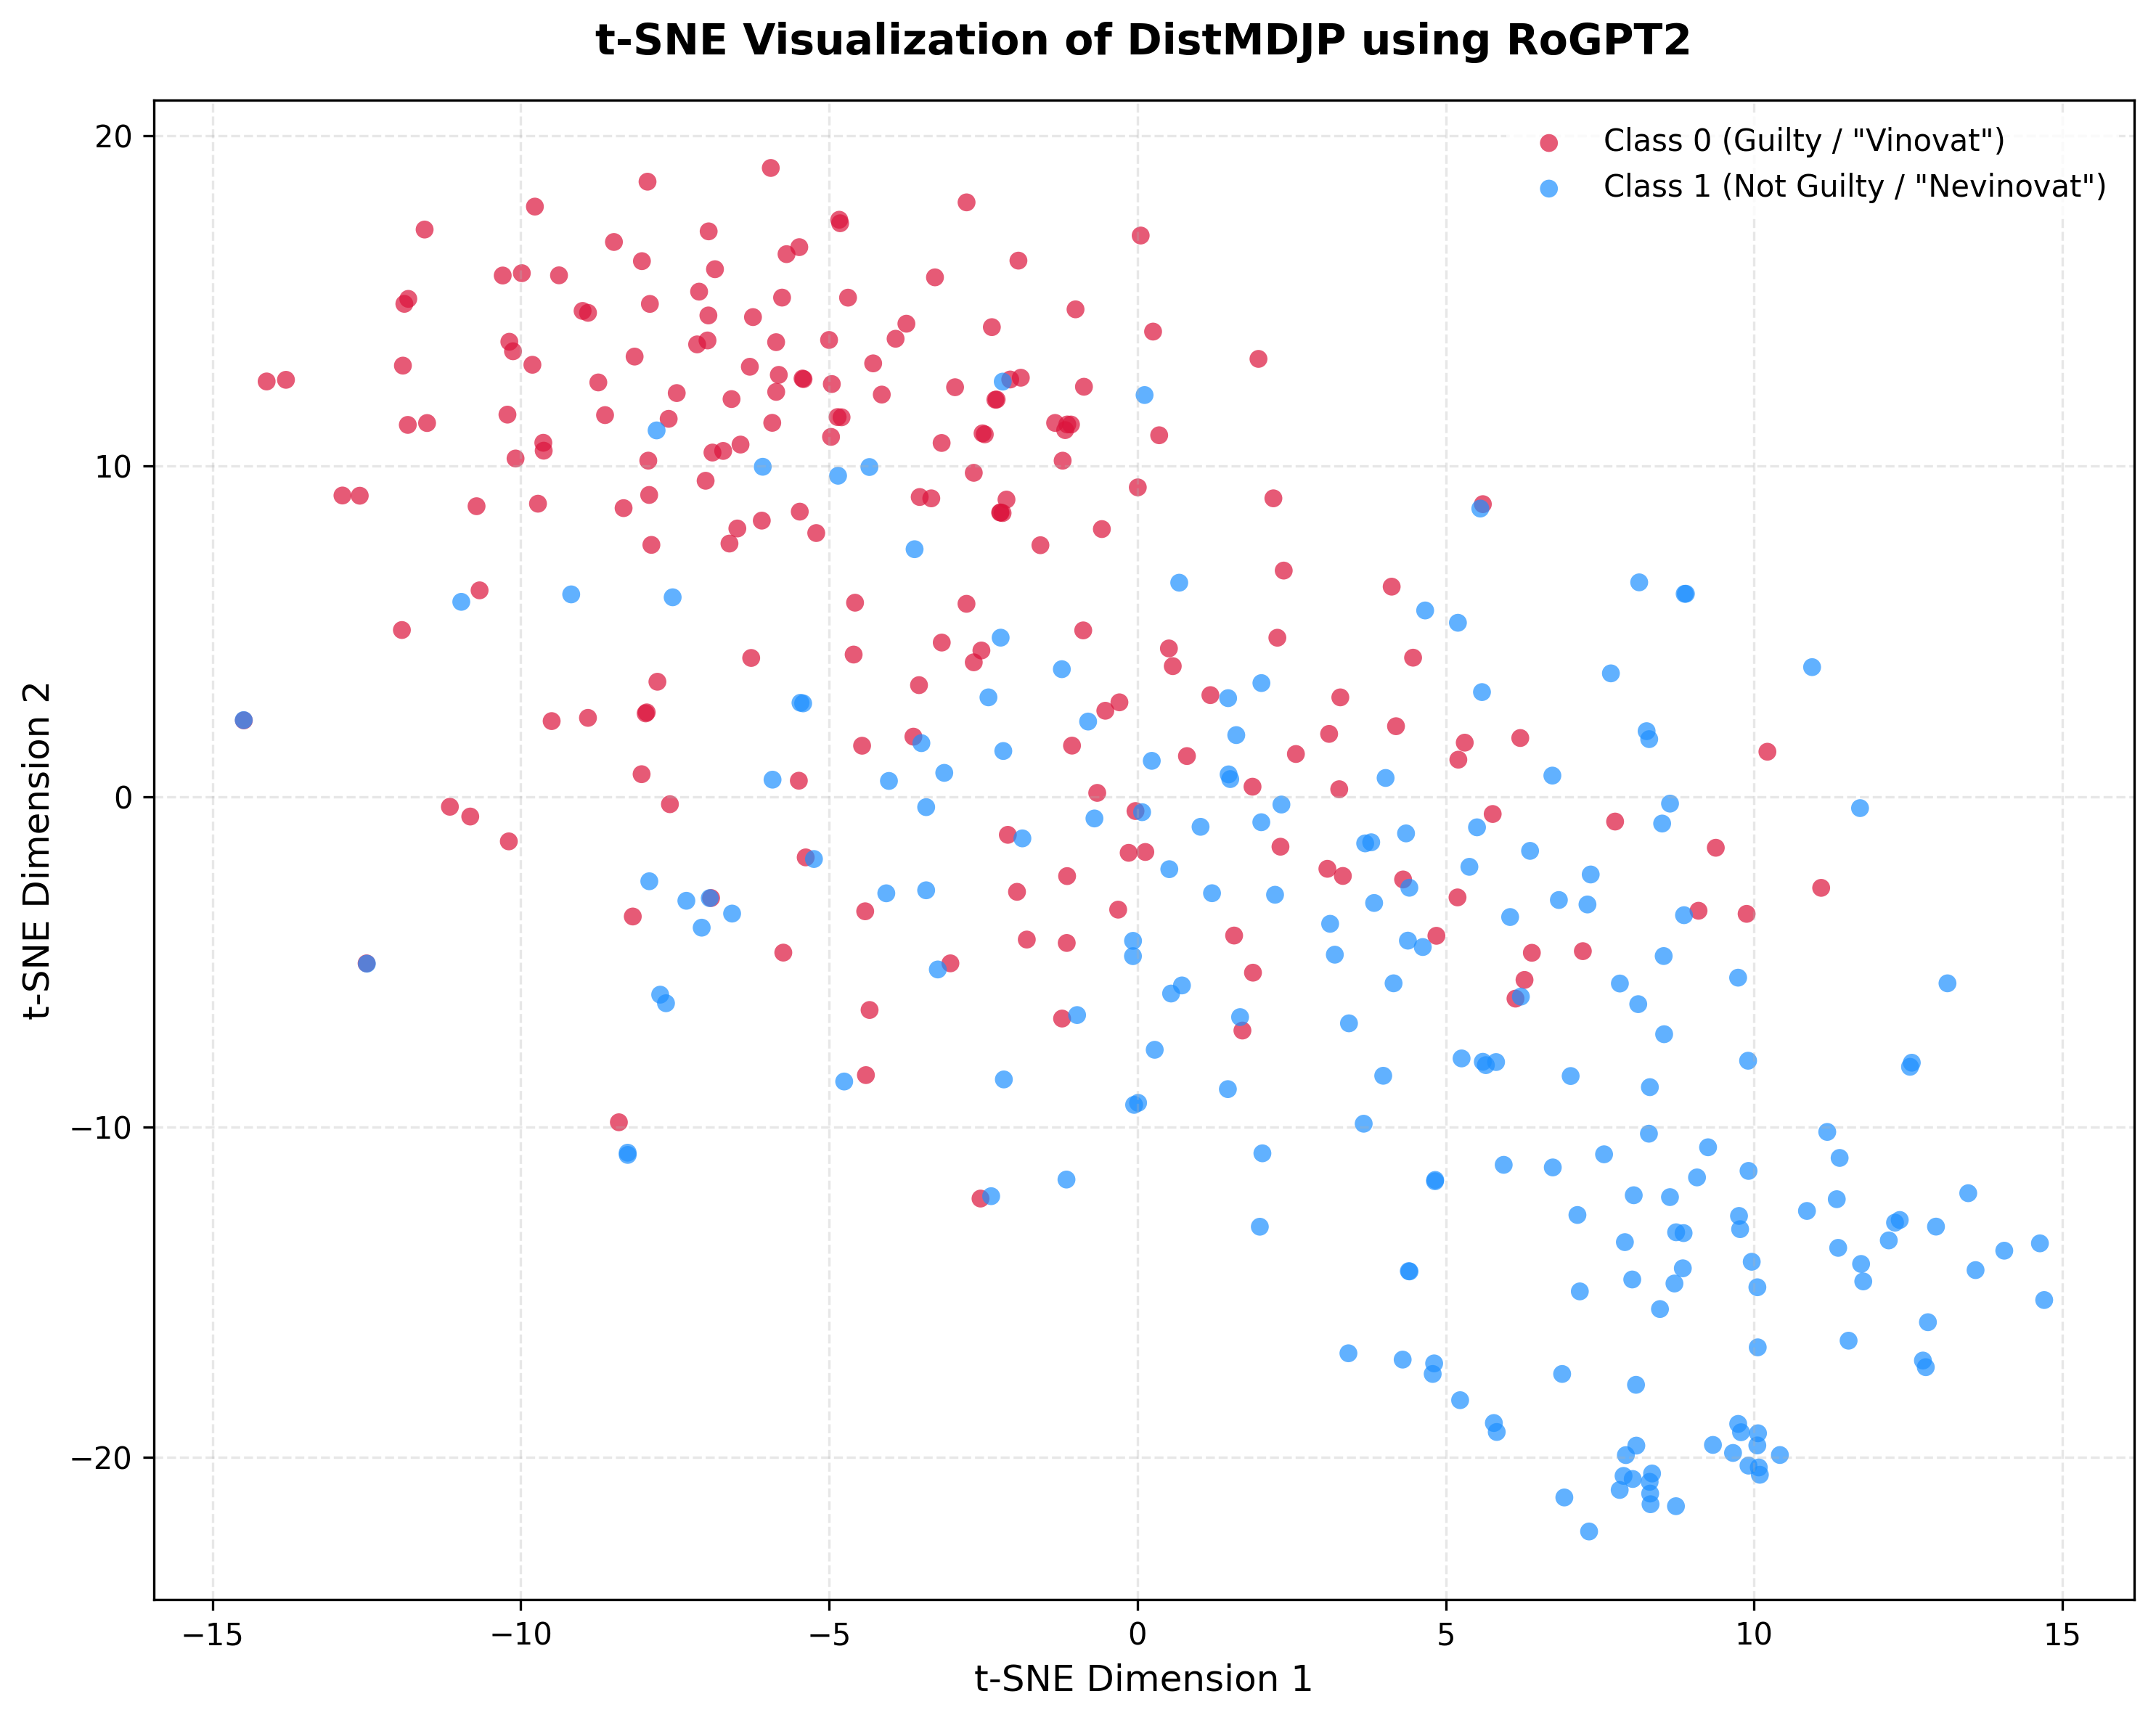

In [5]:
checkpoint_path_rogpt2 = "results/good/dist-ro-gpt2-base/checkpoint-1416"
rogpt2 = AutoModelForSequenceClassification.from_pretrained(checkpoint_path_rogpt2).to(device)
rogpt2.eval()
tokenizer_gpt2 = AutoTokenizer.from_pretrained("readerbench/RoGPT2-base")
tokenizer_gpt2.pad_token = tokenizer_gpt2.eos_token
tokenizer_gpt2.padding_side = "right"
print(f"Model loaded from {checkpoint_path_rogpt2}")


visualize_tsne(path_dist, rogpt2, tokenizer_gpt2, True, "DistMDJP using RoGPT2", 0)

Model loaded from results/good/dist-ro-bert-base/checkpoint-1888
Balancing dataset labels for t-SNE...


Filter: 100%|██████████| 8870/8870 [00:00<00:00, 61269.94 examples/s]


Sampling an equal distribution of 200 items per label (Total: 400)
Extracting high-dimensional embeddings...
Computing t-SNE dimensionality reduction...


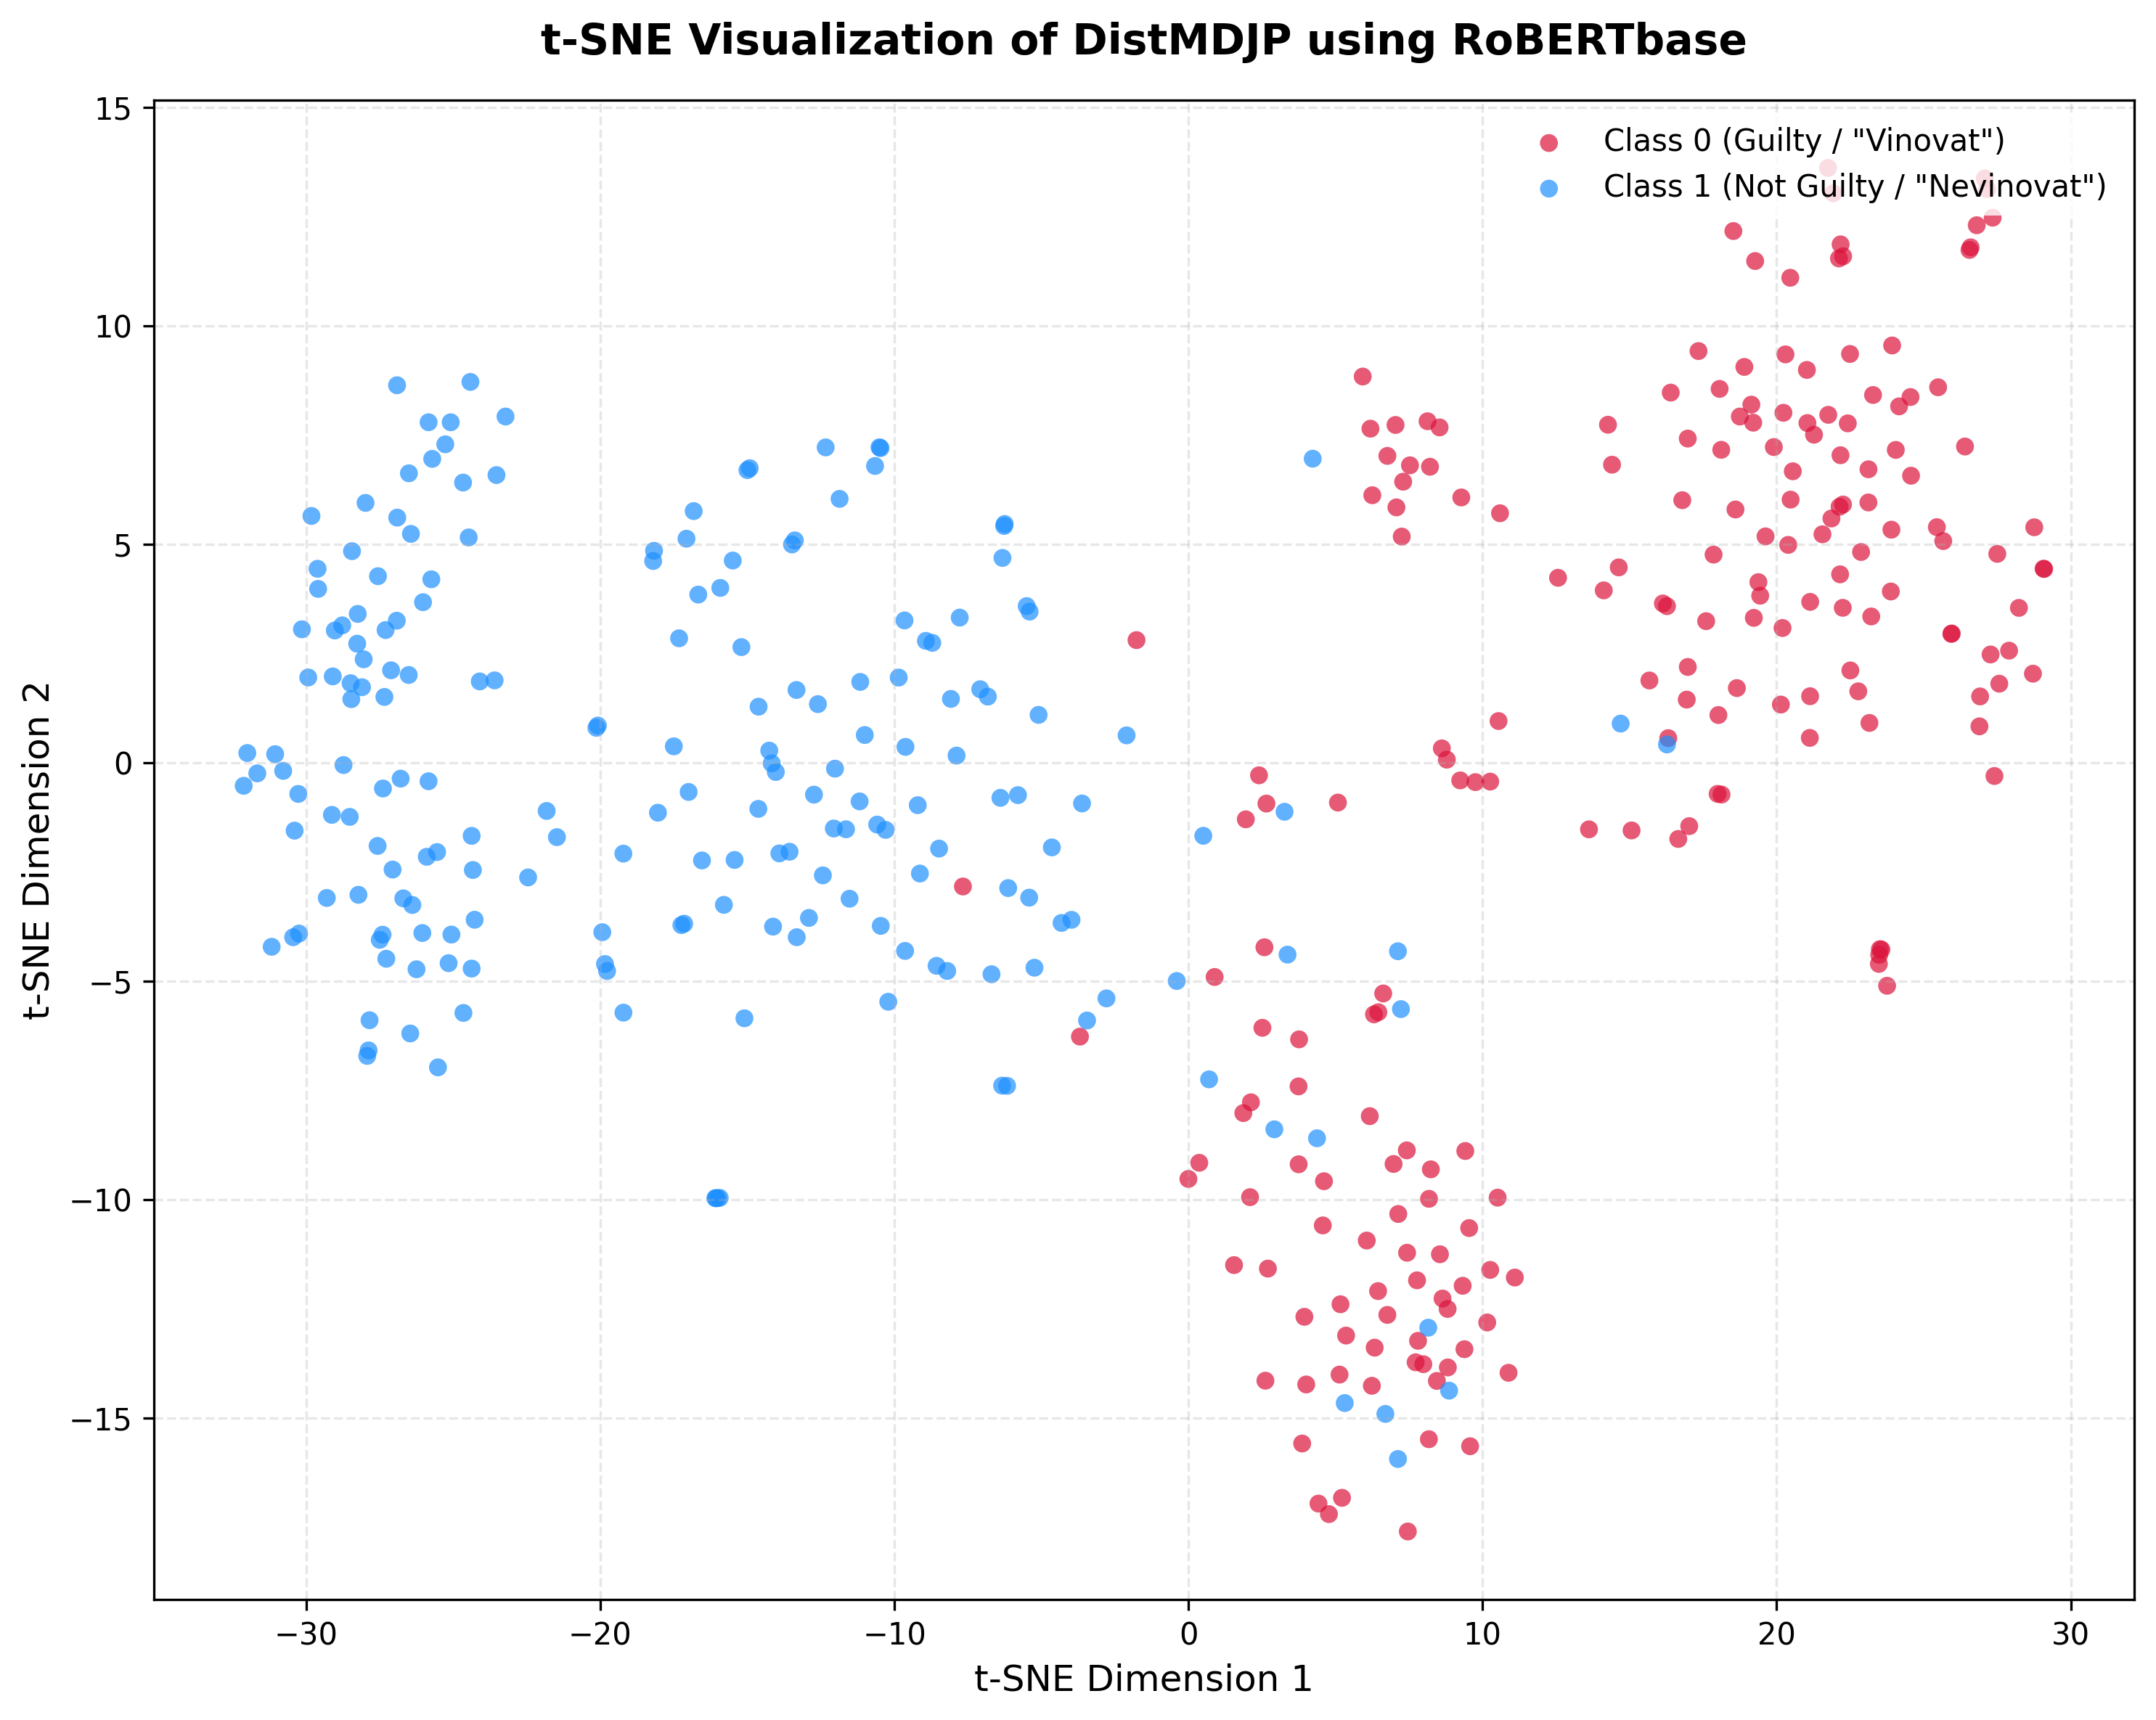

In [6]:
checkpoint_path_robertbase = "results/good/dist-ro-bert-base/checkpoint-1888"
robertbase = AutoModelForSequenceClassification.from_pretrained(checkpoint_path_robertbase).to(device)
robertbase.eval()
tokenizer_robertbase = AutoTokenizer.from_pretrained("dumitrescustefan/bert-base-romanian-cased-v1")
print(f"Model loaded from {checkpoint_path_robertbase}")

visualize_tsne(path_dist, robertbase, tokenizer_robertbase, False, "DistMDJP using RoBERTbase", 0)

Model loaded from results/good/supreme-robertbase-2-labels/checkpoint-440
Balancing dataset labels for t-SNE...


Filter: 100%|██████████| 812/812 [00:00<00:00, 167838.30 examples/s]

Sampling an equal distribution of 200 items per label (Total: 400)
Extracting high-dimensional embeddings...


Computing t-SNE dimensionality reduction...


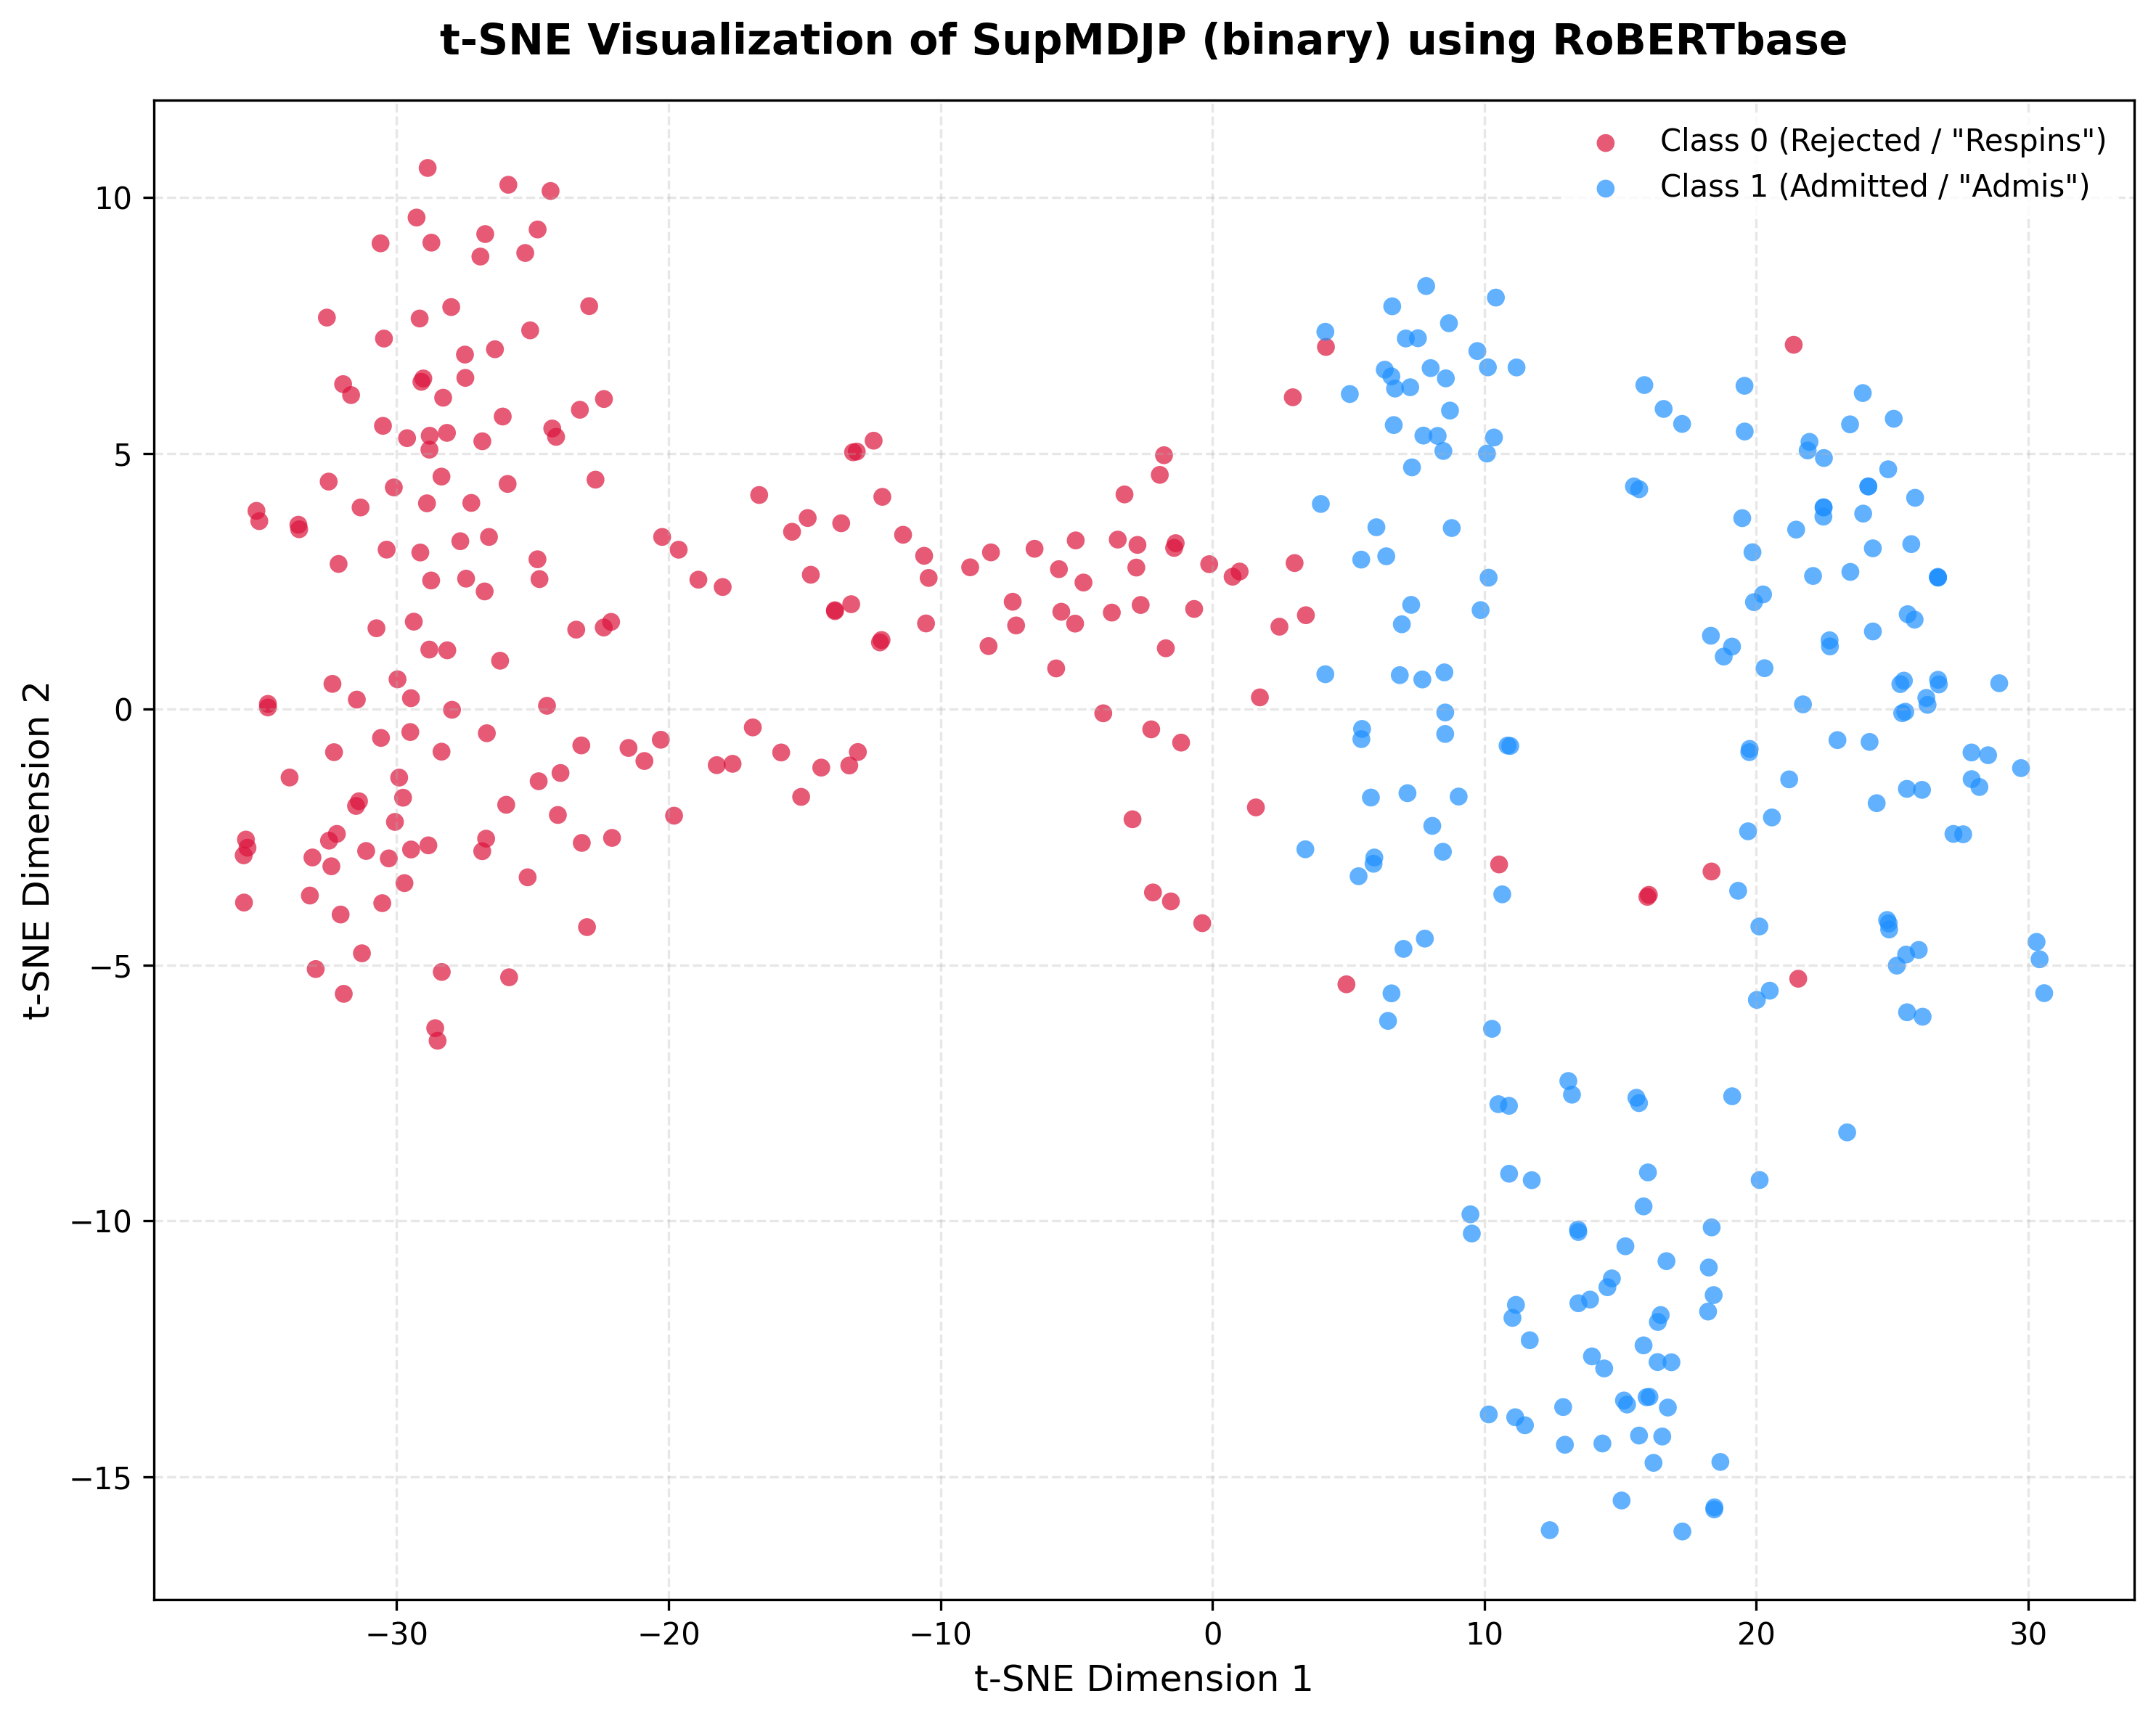

In [7]:
checkpoint_path_robertbase = "results/good/supreme-robertbase-2-labels/checkpoint-440"
robertbase = AutoModelForSequenceClassification.from_pretrained(checkpoint_path_robertbase).to(device)
robertbase.eval()
tokenizer_robertbase = AutoTokenizer.from_pretrained("dumitrescustefan/bert-base-romanian-cased-v1")
print(f"Model loaded from {checkpoint_path_robertbase}")

visualize_tsne(path_sup, robertbase, tokenizer_robertbase, False, "SupMDJP (binary) using RoBERTbase", 2)

Model loaded from results/good/supreme-robertbase-3-labels/checkpoint-375
Balancing dataset labels for t-SNE...


Filter: 100%|██████████| 1400/1400 [00:00<00:00, 89672.52 examples/s]

Sampling an equal distribution of 200 items per label (Total: 400)
Extracting high-dimensional embeddings...


Computing t-SNE dimensionality reduction...


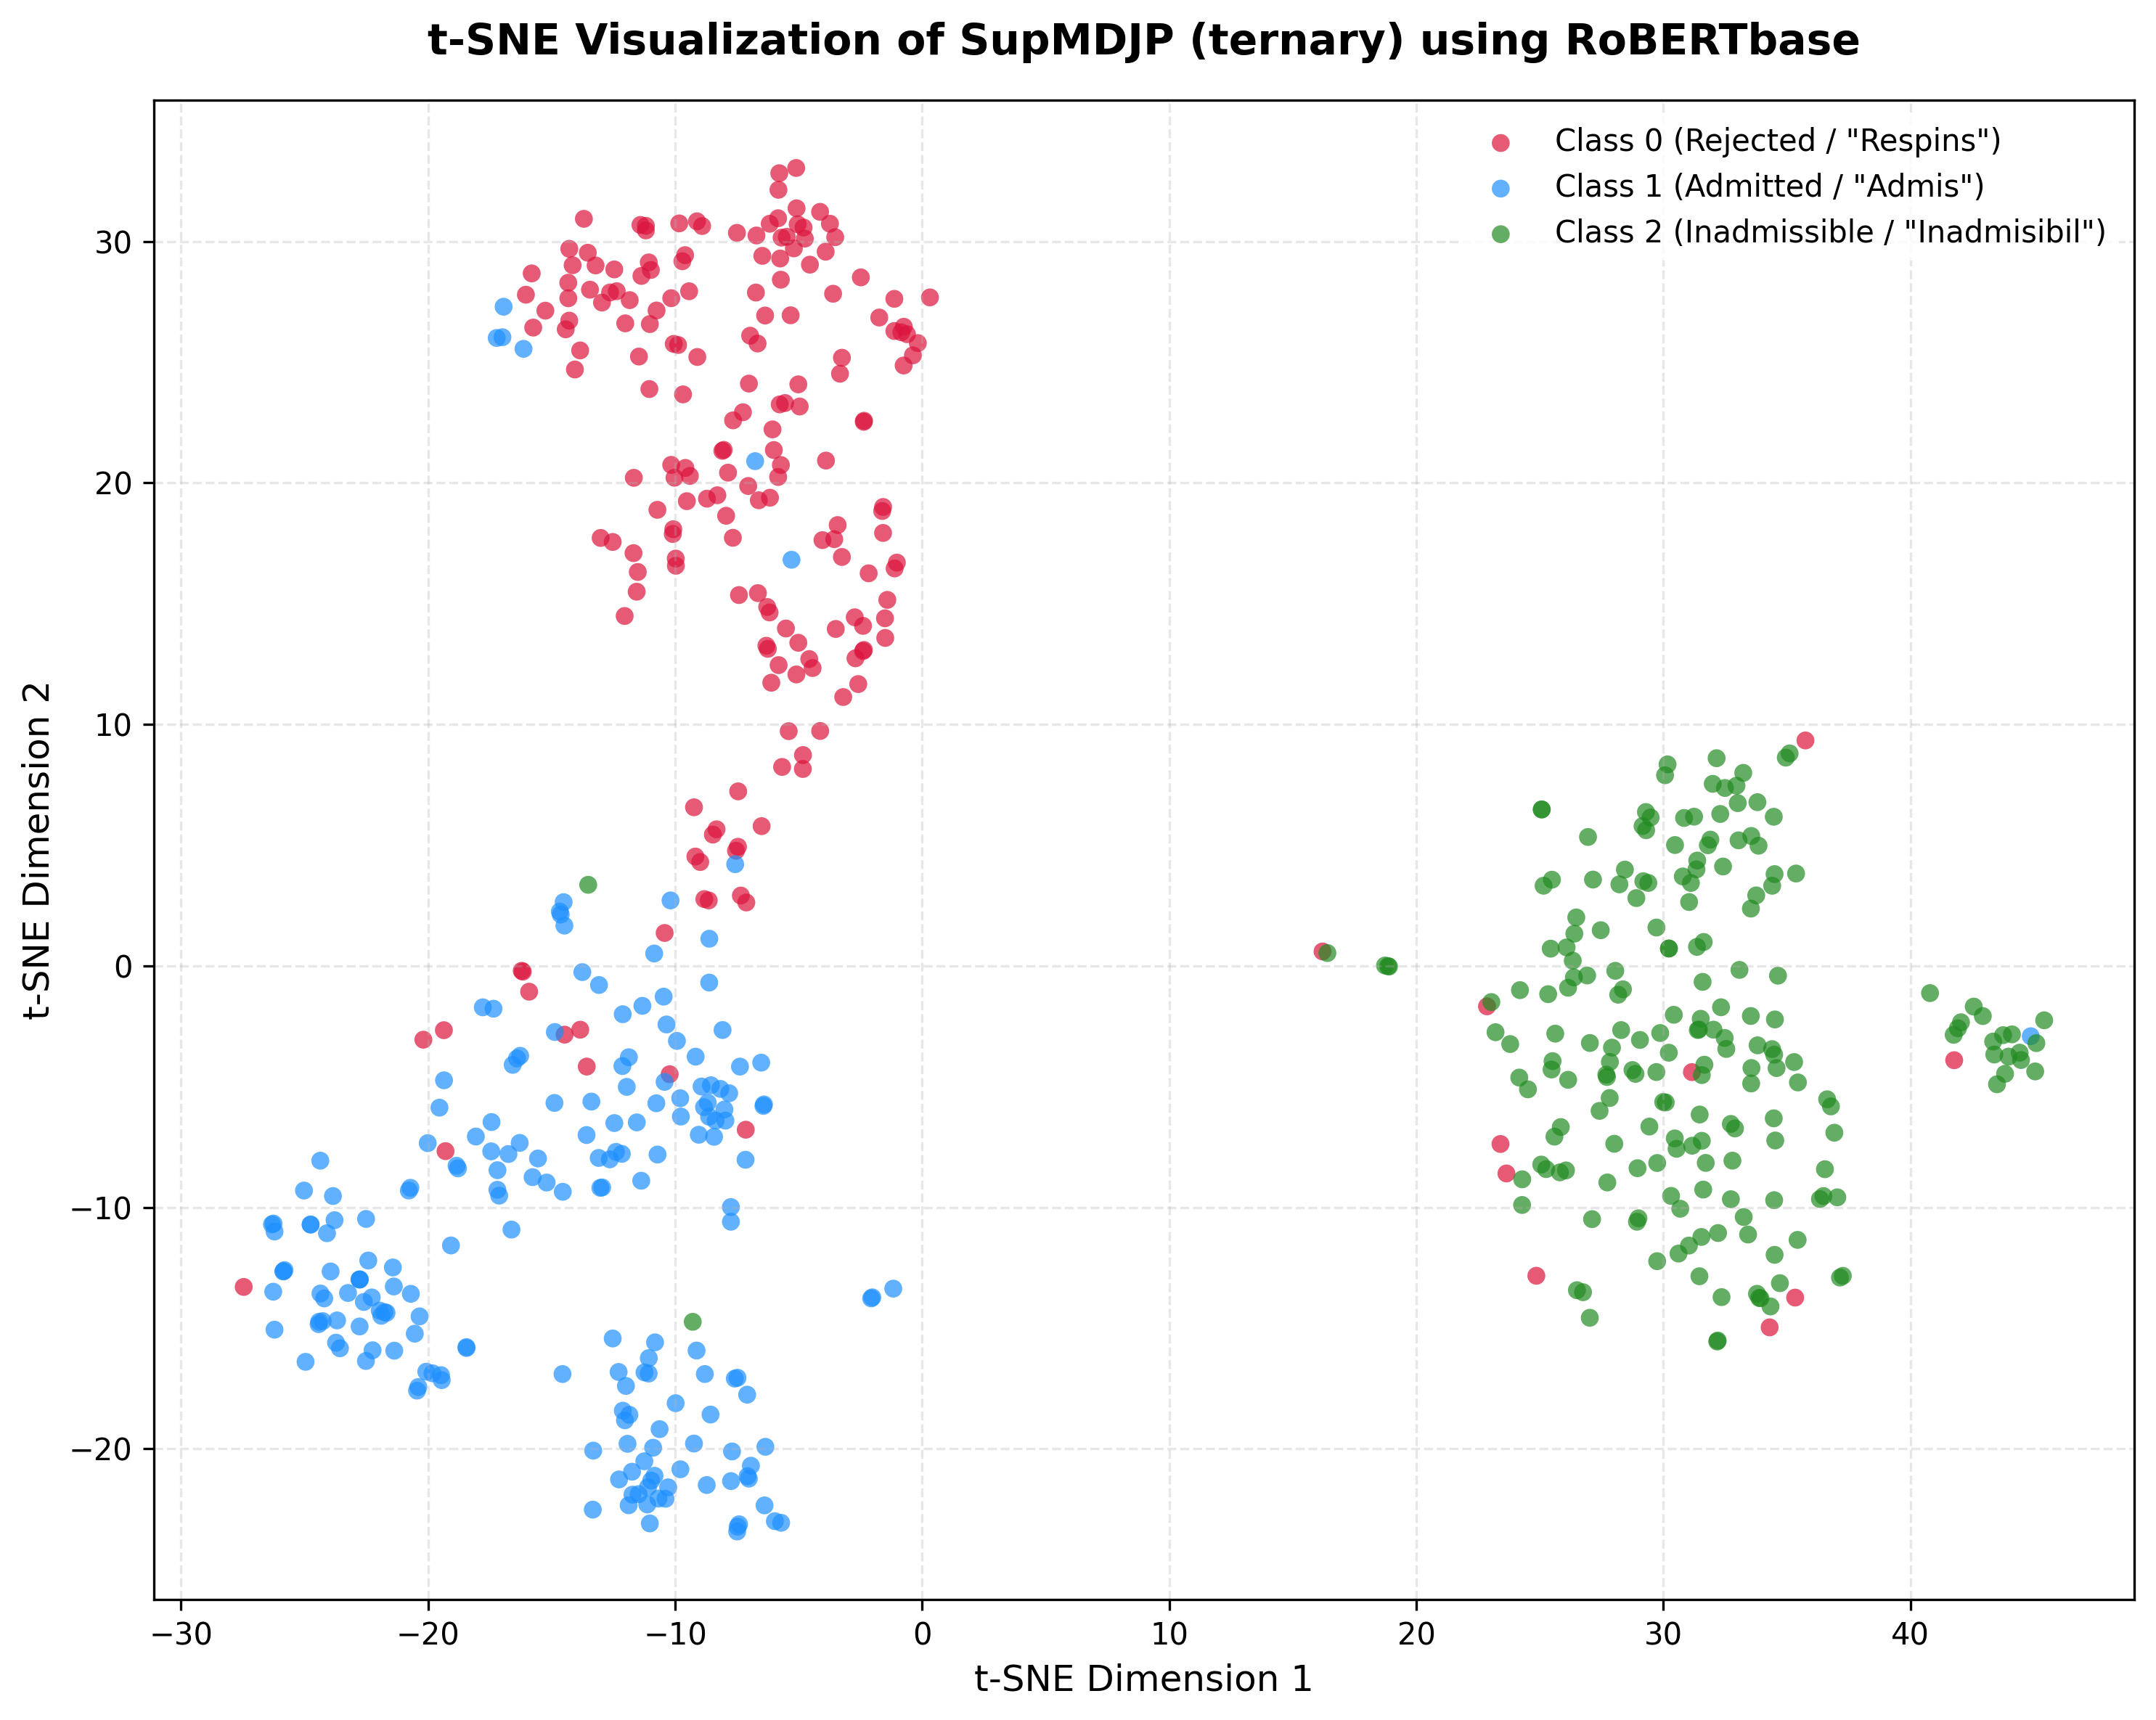

In [8]:
checkpoint_path_robertbase = "results/good/supreme-robertbase-3-labels/checkpoint-375"
robertbase = AutoModelForSequenceClassification.from_pretrained(checkpoint_path_robertbase).to(device)
robertbase.eval()
tokenizer_robertbase = AutoTokenizer.from_pretrained("dumitrescustefan/bert-base-romanian-cased-v1")
print(f"Model loaded from {checkpoint_path_robertbase}")

visualize_tsne(path_sup, robertbase, tokenizer_robertbase, False, "SupMDJP (ternary) using RoBERTbase", 3)